## TASK 5 
### Generative Models 
 - Model Adapted from the official PyTorch DCGAN tutorial

Starting Training Loop...
Epoch [1/200]  Loss_D: 0.5294  Loss_G: 1.2631
Epoch [2/200]  Loss_D: 0.7009  Loss_G: 0.9756
Epoch [3/200]  Loss_D: 0.4502  Loss_G: 2.1209
Epoch [4/200]  Loss_D: 0.7169  Loss_G: 1.3981
Epoch [5/200]  Loss_D: 0.8009  Loss_G: 2.0994
Epoch [6/200]  Loss_D: 0.9017  Loss_G: 3.7655
Epoch [7/200]  Loss_D: 0.7714  Loss_G: 1.6514
Epoch [8/200]  Loss_D: 0.5296  Loss_G: 2.3780
Epoch [9/200]  Loss_D: 0.5695  Loss_G: 2.9386
Epoch [10/200]  Loss_D: 0.4899  Loss_G: 1.4376
Epoch [11/200]  Loss_D: 0.8935  Loss_G: 1.7823
Epoch [12/200]  Loss_D: 0.5445  Loss_G: 1.8166
Epoch [13/200]  Loss_D: 0.7037  Loss_G: 1.4547
Epoch [14/200]  Loss_D: 0.7464  Loss_G: 0.8766
Epoch [15/200]  Loss_D: 0.5803  Loss_G: 3.5919
Epoch [16/200]  Loss_D: 1.3468  Loss_G: 3.0878
Epoch [17/200]  Loss_D: 0.4278  Loss_G: 2.7131
Epoch [18/200]  Loss_D: 0.4862  Loss_G: 1.8524
Epoch [19/200]  Loss_D: 0.4898  Loss_G: 2.6383
Epoch [20/200]  Loss_D: 0.5163  Loss_G: 2.8760
Epoch [21/200]  Loss_D: 0.5133  Loss_G: 1.2

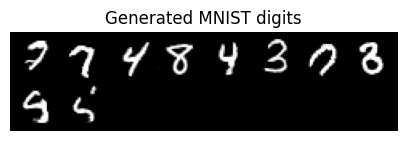

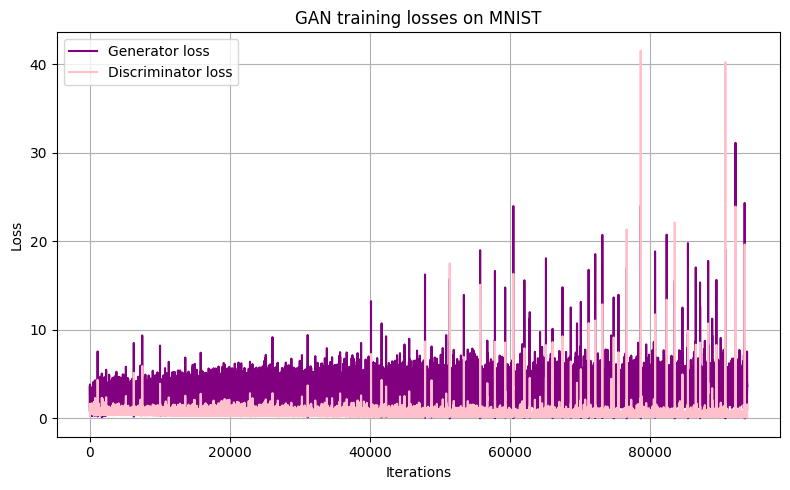

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt

# reproducibility
manualSeed = 999
torch.manual_seed(manualSeed)
np.random.seed(manualSeed)

# basic settings
dataroot = "./data"
workers = 2
batch_size = 128
image_size = 28
nc = 1          # image channels
nz = 100        # latent vector size
ngf = 64        # generator feature maps
ndf = 64        # discriminator feature maps
num_epochs = 200
lr = 0.0002
beta1 = 0.5
ngpu = 1

# dataset
dataset = dset.MNIST(
    root=dataroot,
    download=True,
    transform=transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=workers
)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# generator
class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 4, 7, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# discriminator
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf * 2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, 1, 7, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

# models
netG = Generator(ngpu).to(device)
netD = Discriminator(ngpu).to(device)

# loss and noise
criterion = nn.BCELoss()
fixed_noise = torch.randn(10, nz, 1, 1, device=device)

# optimizers
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# track losses
G_losses = []
D_losses = []

print("Starting Training Loop...")

# training loop
for epoch in range(num_epochs):
    for i, (data, _) in enumerate(dataloader):

        # train discriminator
        netD.zero_grad()
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), 1., device=device)

        output = netD(real_cpu)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.)

        output = netD(fake.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        optimizerD.step()

        # train generator
        netG.zero_grad()
        label.fill_(1.)
        output = netD(fake)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

        G_losses.append(errG.item())
        D_losses.append((errD_real + errD_fake).item())

    # save samples at some epochs
    if (epoch + 1) in [1, 25, 50, 75, 100, 125, 150, 175, 200]:
        with torch.no_grad():
            fake = netG(fixed_noise).detach().cpu()
        vutils.save_image(
            fake,
            f"gan_epoch_{epoch+1}.png",
            normalize=True,
            nrow=5
        )

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss_D: {(errD_real+errD_fake).item():.4f}  Loss_G: {errG.item():.4f}")

# final generated samples
with torch.no_grad():
    fake = netG(fixed_noise).detach().cpu()

plt.figure(figsize=(5, 5))
plt.axis("off")
plt.title("Generated MNIST digits")
plt.imshow(np.transpose(vutils.make_grid(fake, padding=2, normalize=True), (1, 2, 0)))
plt.savefig("gan_generated_mnist.png", dpi=300)
plt.show()

# loss curves
plt.figure(figsize=(8,5))
plt.plot(G_losses, label="Generator loss", color="purple")
plt.plot(D_losses, label="Discriminator loss", color="pink")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("GAN training losses on MNIST")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gan_training_losses.png", dpi=300)
plt.show()
